<a href="https://colab.research.google.com/github/Misbahuddin111/deep-learning/blob/main/13_optimzers_in_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## SSD WITH MOMENTUM

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.layers import Dense , Dropout
from keras.optimizers import SGD
from keras.models import Sequential
# 1. Load and preprocess data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28*28).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 28*28).astype("float32") / 255.0

# create archituter


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])
# initialize optimizer
optimizer = SGD(
    learning_rate = 0.01,
    momentum = 0.9,
    nesterov=True
)

# compile the model
model.compile(loss="sparse_categorical_crossentropy",
              optimizer = optimizer,
              metrics = ["accuracy"]
             )
# 4. Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)





11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8044 - loss: 0.6419 - val_accuracy: 0.9357 - val_loss: 0.2211
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9091 - loss: 0.3090 - val_accuracy: 0.9548 - val_loss: 0.1544
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9289 - loss: 0.2426 - val_accuracy: 0.9642 - val_loss: 0.1271
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9406 - loss: 0.2008 - val_accuracy: 0.9715 - val_loss: 0.1048
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9480 - loss: 0.1761 - val_accuracy: 0.9727 - val_loss: 0.0962
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9530 - loss: 0.1568 - val_accuracy: 0.9747 - val_loss: 0.0918
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9568 - loss: 0.1444 - val_accuracy: 0.9752 - val_loss: 0.0836
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9604 - loss: 0.1316 - val_accuracy: 0.

test_accuracy = 0.9739000201225281 


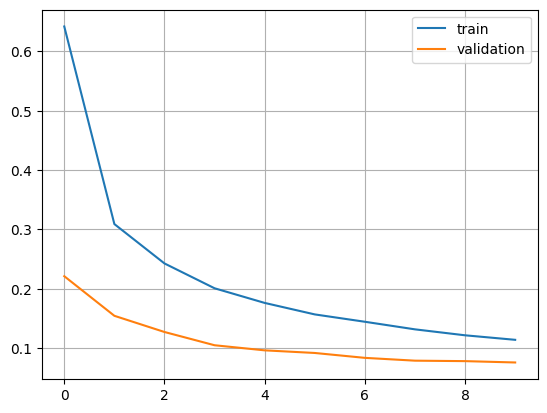

In [3]:
# Evaluate
import matplotlib.pyplot as plt
test_loss , test_accuracy = model.evaluate(x_test,y_test,verbose=0)
print(f"test_accuracy = {test_accuracy} ")
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(['train','validation'])
plt.grid()
plt.show()